In [1]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
pd.set_option('display.max_columns', None)
import time
import warnings
warnings.filterwarnings("ignore")
import os
import sys

In [2]:
import data_utils
import models

In [3]:
from utils import xgb_eval, lgbm_eval, catb_eval
from expl_utils import inverse_transform_rule_complete

# Load Dataset

In [4]:
# dataset_name= 'adult'
dataset_name= 'compas'
# dataset_name= 'fico'
# dataset_name= 'churn'
# dataset_name= 'breast'

# dataset_name= 'ecoli'
# dataset_name= 'wine'

data_dict = data_utils.get_tabular_dataset(dataset_name, random_state=42)

In [5]:
X_train, X_test, y_train, y_test = data_dict['X_train'], data_dict['X_test'], data_dict['y_train'], data_dict['y_test']

In [6]:
features_map = data_dict['features_map']
idx_num_cat = [list(d.values()) for i,d in features_map.items()]

# Train Black-Box

In [60]:
clf, clf_score = lgbm_eval(X_train, y_train, X_test, y_test, random_state=42)
print(clf_score)

0.951575906889814


In [62]:
y_train_pred = clf.predict_proba(X_train)
y_test_pred = clf.predict_proba(X_test)

# Latent Encoding Training

## Run the code for training a dense meta-encoding.

encdec=
- 'linear' : for a single global linear transformation
- 'local_linear':  for individual linear transformations

In [8]:
latent = models.ILLUME(encdec='local_linear', max_epochs=500, latent_dim=6, batch_size=1024, early_stopping=30)

Important inputs:
- X=(X_train, X_test) : train/validation sets for validation accuracy / early stopping
- y=(y_train_pred, y_test_pred) : predicted black-box probabilities (optional)
- idx_num_cat : list of lists with numerical/categorical features indices
- params_dict : dictionary with regularization parameters

Keys in params_dict:
- 'num_k': number of non-zero weights per row in the encoder transformation matrix. None means all non-zero weights  
- 'l_so': set to 1.0 to enable orthogonalization of the encoder transformation matrix (only if 'num_k'!= None) 
- 'l_rec': set to 1.0 to enable training a non-linear decoder 
- 'l_kld': set to 1.0 to optimize distances distribution
- 'l_co': set to 1.0 to optimize non-collinearity of latent features
- 'l_st': set to 1.0 to optimize local stability of individual linear transformations (only if encdec='param_encdec')

In [9]:
losses = latent.fit(X=(X_train, X_test),                   
                    y=(y_train_pred, y_test_pred),               
                    idx_num_cat=idx_num_cat,                       
                    params_dict={'num_k':None, 'l_rec':0.0, 'l_kld':1.0,      # dictionary with regularization parameters
                            'l_so':0.0, 'l_co':1.0, 'l_st':1.0},
                    seed=42)

Training Meta-encoder with max 500 iterations.


Epoch: 223 Train Loss 0.03462 Test Loss 0.03547 Early Stopping 30

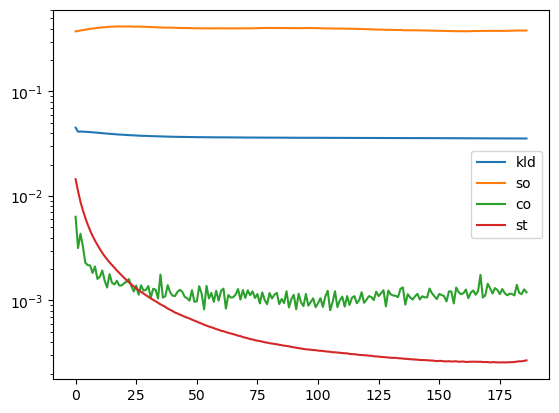

In [10]:
# plt.plot(np.array(losses[0])[:,1:-1], label=['kld', 'so', 'co', 'st'])
plt.plot(np.array(losses[1])[:,1:-1], label=['kld', 'so', 'co', 'st'])
plt.yscale('log')
plt.legend()

Text(0.5, 1.0, 'Space Z')

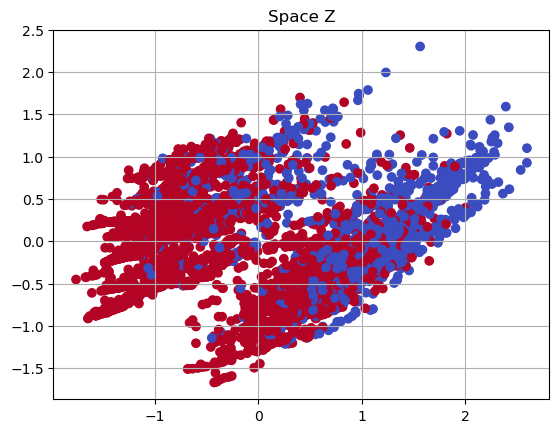

In [11]:
from sklearn.decomposition import PCA

Z = latent.Z_train.copy()
Y = latent.y_train[:,1].copy()
Z = PCA().fit_transform(Z)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space Z')

Text(0.5, 1.0, 'Space W')

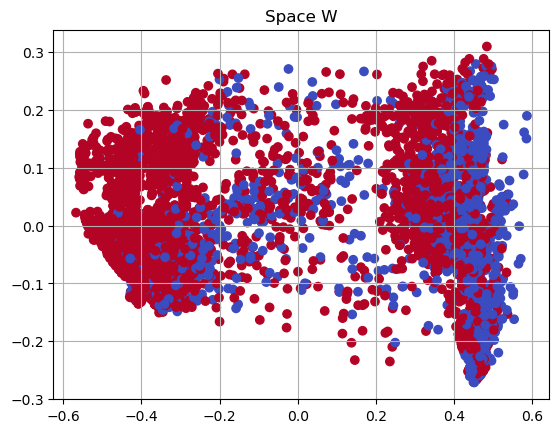

In [12]:
from sklearn.decomposition import PCA

W = latent.W_train.reshape(-1, np.prod(latent.W_train.shape[1:]))
Y = latent.y_train[:,1].copy()
Z = PCA().fit_transform(W)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space W')

# Latent Encoding with Sparsity

### The code here should be run after pre-training dense meta-encoding in the previous section. Skip this section if you are not interested in sparsity constraints.

In [60]:
#tune sparse model by incrementally adding sparsity every 30 epochs

losses = latent.fit(X=(X_train, X_test),                   # train/test sets for validation accuracy / early stopping 
                    y=(y_train_pred, y_test_pred),               # predicted probabilities 
                    idx_num_cat=idx_num_cat,                      # numerical/categorical indices 
                    params_dict={'num_k':2, 'l_rec':0.0, 'l_kld':1.0,         # dictionary with regularization parameters
                            'l_so':1.0, 'l_co':0.0, 'l_st':1.0},
                    seed=42)

Training Meta-encoder with sparsity scheduling with max 650 iterations.


Epoch: 650 Train Loss 0.03457 Test Loss 0.03488 Early Stopping 1 

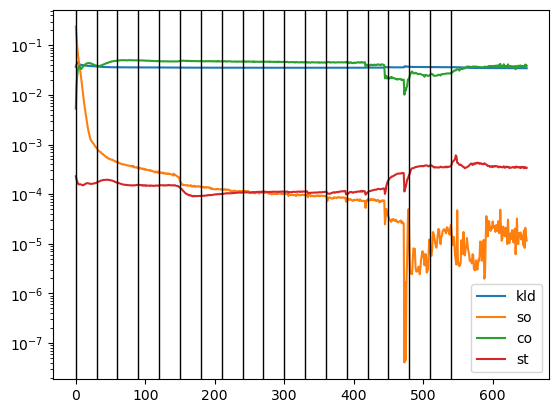

In [68]:
# plt.plot(np.array(losses[0])[:,1:-1], label=['kld',  'so', 'co', 'st'])
plt.plot(np.array(losses[1])[:,1:-1], label=['kld',  'so', 'co', 'st'])
for i in range(X_train.shape[1]-1):
    plt.axvline(x = 30*i, color = 'k', linewidth=1)
plt.yscale('log')
plt.legend()

Text(0.5, 1.0, 'Space Z')

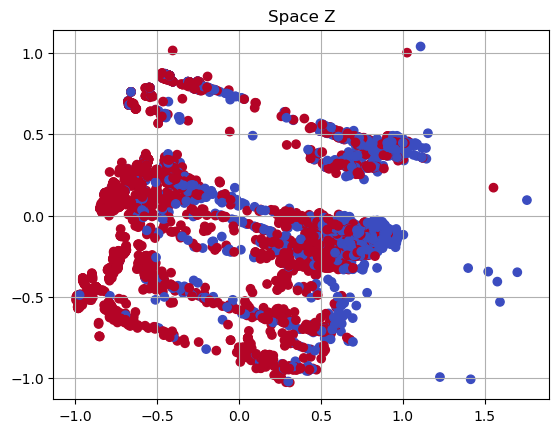

In [69]:
from sklearn.decomposition import PCA

Z = latent.Z_train.copy()
Y = latent.y_train[:,1].copy()
Z = PCA().fit_transform(Z)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space Z')

Text(0.5, 1.0, 'Space W')

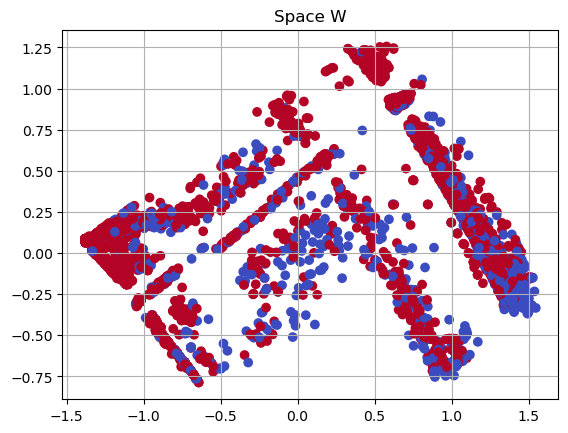

In [70]:
from sklearn.decomposition import PCA

W = latent.W_train.reshape(-1, np.prod(latent.W_train.shape[1:]))
Y = latent.y_train[:,1].copy()
Z = PCA().fit_transform(W)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space W')

# Surrogates Training

In [23]:
y_train_bb = clf.predict(X_train)
y_test_bb = clf.predict(X_test)

## Run the code for training Logistic and Tree classifier

In [11]:
latent.explain(1)

Training Logistic Regression surrogate.
LR surrogate score: 0.7104
Generating feature importance for training set.

Training Decision Tree surrogate.
DT surrogate score: 0.7225
Generating factual and counterfactual rules for training set.



## Feature importance

In [19]:
fimp = latent.get_feature_importance(X_test, y_test_bb)

In [20]:
fimp = [{f: expl[i] for i,f in enumerate(data_dict['feature_names'])} 
        for expl in fimp]

In [21]:
fimp = [{f: expl[f] for i,f in enumerate(data_dict['feature_names']) 
         if (f in data_dict['numeric_columns'] or x[i]==1.)} 
        for expl,x in zip(fimp, X_test)]

## Decision Rules

##### Factual rules

In [24]:
rules = latent.get_decision_rules(X_test, y_test_bb)

In [25]:
rules = [inverse_transform_rule_complete(expl, data_dict['scaler'], latent.idx_num) for expl in rules]

In [26]:
rules = [{(f,eq): expl[(f'x{i}', eq)] 
          for i,f in enumerate(data_dict['feature_names']) for eq in ['<=', '>'] 
          if (expl[(f'x{i}', eq)] not in [np.inf, -np.inf])} 
         for expl in rules]

In [29]:
rules = [{(f,eq) if f in data_dict['numeric_columns'] else (f.split('=')[0], ('=' if eq=='>' else '!=')): 
          (expl[(f,eq)] if (f in data_dict['numeric_columns']) else f.split('=')[1]) 
          for f,eq in expl} 
         for expl in rules]

##### CF Rules

In [156]:
crules = latent.get_decision_crules(X_test, y_test_bb)

In [157]:
crules = [inverse_transform_rule_complete(ex, data_dict['scaler'], latent.idx_num) for ex in crules]

In [158]:
crules = [{(f,eq): ex[(f'x{i}', eq)] for i,f in enumerate(data_dict['feature_names']) for eq in ['<=', '>'] if (ex[(f'x{i}', eq)] not in [np.inf, -np.inf])} for ex in crules]

In [160]:
crules = [{(f,eq) if f in data_dict['numeric_columns'] else (f.split('=')[0], ('=' if eq=='>' else '!=')): 
          (expl[(f,eq)] if (f in data_dict['numeric_columns']) else f.split('=')[1]) 
          for f,eq in expl} 
         for expl in crules]